# EDA 3.0: Xử lý Tín hiệu Số (DSP) - Khai phá Hiện tượng Over-smoothing bằng Azimuthal Average 1D

> [!CAUTION]
> **Lỗ hổng của Biểu đồ FFT 2D:** Biểu đồ FFT 2D hiển thị tần số dưới dạng một mặt phẳng, rất khó để định lượng bằng mắt. 
> 
> **Phương pháp Tối thượng:** 
> Chúng ta sẽ tính toán **1D Azimuthal Average (Trung bình phương vị 1D)**. Kỹ thuật này sẽ lấy tích phân toàn bộ góc quay của phổ 2D thành một đồ thị 1D duy nhất. Tại dải cao tần, StyleGAN3 lộ rõ điểm yếu: **Hiện tượng Over-smoothing (Làm mịn quá đà)**. Ảnh GAN thiếu đi các chi tiết vi mô (micro-textures như lỗ chân lông, nếp nhăn vi thể), dẫn đến mức Năng lượng (Power Spectrum) sụt giảm hẳn và chìm xuống bên dưới ảnh Real.


f:\DeepLearning_Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bắt đầu xử lý tín hiệu...


Calculating 1D Spectrum: 100%|██████████| 2000/2000 [00:13<00:00, 143.58it/s]


Đã xuất số liệu 1D Spectrum ra file: frequency_1d_spectrum.csv


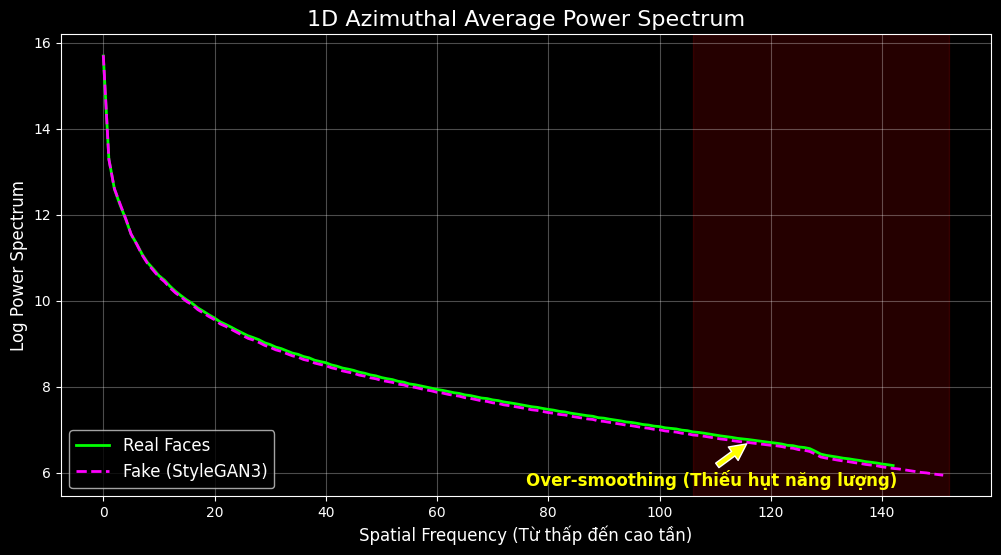

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from glob import glob
import os
from tqdm import tqdm

plt.style.use('dark_background')

def compute_azimuthal_average(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    
    # Tính Fourier Transform
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    
    # Tạo lưới tọa độ cực để tính Azimuthal Average
    h, w = magnitude.shape
    y, x = np.indices((h, w))
    center = (h // 2, w // 2)
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(np.int32)
    
    tbin = np.bincount(r.ravel(), magnitude.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    
    return np.log(radialprofile + 1)

base_dir = "../data"
real_images = [f for f in glob(os.path.join(base_dir, '**', '*.*'), recursive=True) if 'real' in f.lower() and f.lower().endswith(('.png', '.jpg'))]
fake_images = [f for f in glob(os.path.join(base_dir, '**', '*.*'), recursive=True) if 'fake' in f.lower() and f.lower().endswith(('.png', '.jpg'))]

sample_size = 2000
np.random.seed(42)
r_samp = np.random.choice(real_images, min(sample_size, len(real_images)), replace=False) if len(real_images) > 0 else []
f_samp = np.random.choice(fake_images, min(sample_size, len(fake_images)), replace=False) if len(fake_images) > 0 else []

def get_mean_1d_spectrum(img_list):
    profiles = []
    for p in tqdm(img_list, desc="Calculating 1D Spectrum"):
        prof = compute_azimuthal_average(p)
        if prof is not None:
            profiles.append(prof)
    
    min_len = min([len(p) for p in profiles]) if len(profiles) > 0 else 0
    trimmed = [p[:min_len] for p in profiles]
    return np.mean(trimmed, axis=0) if len(trimmed) > 0 else []

print("Bắt đầu xử lý tín hiệu...")
real_1d = get_mean_1d_spectrum(r_samp)
fake_1d = get_mean_1d_spectrum(f_samp)

fig, ax = plt.subplots(figsize=(12, 6))
if len(real_1d) > 0: ax.plot(real_1d, label='Real Faces', color='#00ff00', linewidth=2)
if len(fake_1d) > 0: ax.plot(fake_1d, label='Fake (StyleGAN3)', color='#ff00ff', linestyle='--', linewidth=2)

ax.set_title('1D Azimuthal Average Power Spectrum', fontsize=16)
ax.set_xlabel('Spatial Frequency (Từ thấp đến cao tần)', fontsize=12)
ax.set_ylabel('Log Power Spectrum', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

# Highlight vùng chênh lệch (High Frequency)
if len(fake_1d) > 0:
    high_freq_start = int(len(fake_1d) * 0.7)
    ax.axvspan(high_freq_start, len(fake_1d), color='red', alpha=0.15, label='High-Frequency Energy Loss')
    # Trỏ vào chỗ Fake nằm DƯỚI Real
    ax.annotate('Over-smoothing (Thiếu hụt năng lượng)', xy=(high_freq_start + 10, fake_1d[high_freq_start + 10]), xytext=(high_freq_start - 30, fake_1d[high_freq_start + 10] - 1),
                arrowprops=dict(facecolor='yellow', shrink=0.05), color='yellow', fontsize=12, fontweight='bold')

# Xuất số liệu Azimuthal 1D ra CSV
import pandas as pd
csv_1d = 'frequency_1d_spectrum.csv'
pd.DataFrame({'Spatial_Frequency_Bin': range(len(real_1d)), 'Real_Power': real_1d, 'Fake_Power': fake_1d[:len(real_1d)]}).to_csv(csv_1d, index=False)
print(f"Đã xuất số liệu 1D Spectrum ra file: {csv_1d}")

plt.show()
